In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


If we observe sound in an anechoic chamber or in an open space, this is called the **free field**:
Sound only propagates directly from a source to the receiver.
In most everyday situations, this is not the case.
Sound is reflected repeatedly from many manysurfaces, ultimately resulting in a so called **diffuse field**:
Sound arrives from every direction with equal probability.

## Components of Reverb

Reverb is a phenomenon that is composed of different components.
When a signal is received in a reverberant space, these include:

1. **Direct Sound** – Reaches the listener first on the shortest possible path.
2. **Early Reflections** – Arrive shortly after, within 50–80 ms and is comprised mostly of first and second order reflections.
3. **Diffuse Reverb** – Dense, decaying series of reflections that is equally distributed in space.

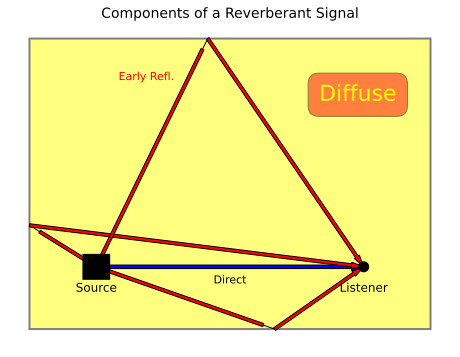

In [55]:

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Draw room boundary
room = patches.Rectangle((0.5, 0.5), 9, 7, linewidth=2, edgecolor='black', facecolor='yellow',alpha=0.5)
ax.add_patch(room)

# Positions
source = (2, 2)
listener = (8, 2)



# Draw source and listener
ax.add_patch(patches.Rectangle((source[0]-0.3, source[1]-0.3), 0.6, 0.6, color='black', zorder=10))
ax.text(source[0], source[1]-0.6, 'Source', ha='center', fontsize=12)

ax.plot(listener[0], listener[1], 'o', color='black', markersize=10, zorder=10)
ax.text(listener[0], listener[1]-0.6, 'Listener', ha='center', fontsize=12)

# Direct path
ax.annotate('', xy=listener, xytext=source, 
            arrowprops=dict(facecolor='blue', shrink=0, width=3.5, headwidth=8))
ax.text((source[0]+listener[0])/2, source[1]-0.4, 'Direct', ha='center', fontsize=11)

# Early reflections
# Left wall reflection
ref1_wall = (0.5, 3)
ax.annotate('', xy=ref1_wall, xytext=source, 
            arrowprops=dict(facecolor='red', shrink=0, width=3.2, headwidth=0))
ax.annotate('', xy=listener, xytext=ref1_wall, 
            arrowprops=dict(facecolor='red', shrink=0, width=3.2, headwidth=6))

# Top wall reflection
ref2_wall = (4.5, 7.5)
ax.annotate('', xy=ref2_wall, xytext=source, 
            arrowprops=dict(facecolor='red', shrink=0, width=3.2, headwidth=0))
ax.annotate('', xy=listener, xytext=ref2_wall, 
            arrowprops=dict(facecolor='red', shrink=0, width=3.2, headwidth=6))


# bottom wall reflection
ref3_wall = (6, 0.5)
ax.annotate('', xy=ref3_wall, xytext=source, 
            arrowprops=dict(facecolor='red', shrink=0, width=3.2, headwidth=0))
ax.annotate('', xy=listener, xytext=ref3_wall, 
            arrowprops=dict(facecolor='red', shrink=0, width=3.2, headwidth=6))


# Labels
ax.text(2.5, 6.5, 'Early Refl.', fontsize=11, color='red')


# Labels
ax.text(7, 6, 'Diffuse', fontsize=22,  color='yellow' ,bbox=dict(facecolor='red', alpha=0.5, edgecolor='black', boxstyle='round,pad=0.5'))


# Title
ax.text(5, 8, 'Components of a Reverberant Signal', ha='center', fontsize=14)

plt.show()


In the time domain, these components can be visualized as follows:

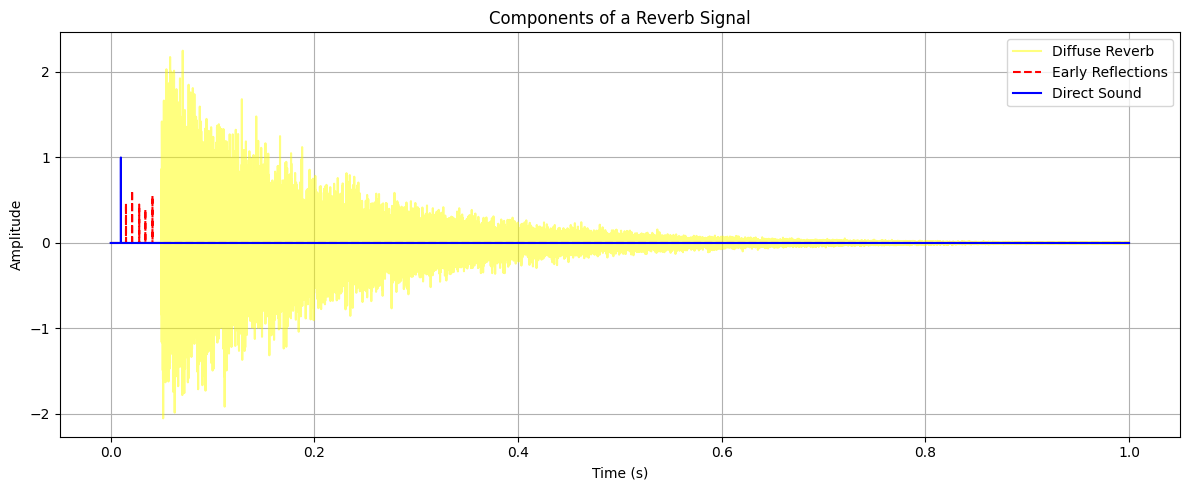

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set up parameters
fs = 48000  # Sample rate
t = np.linspace(0, 1, fs)

# Create each component
direct = np.zeros_like(t)
direct[int(0.01 * fs)] = 1.0

early = np.zeros_like(t)
for delay in [0.015, 0.021, 0.028, 0.034, 0.041]:
    early[int(delay * fs)] = np.random.uniform(0.3, 0.7)

tail = np.random.randn(len(t)) * np.exp(-t * 6)
tail[:int(0.05 * fs)] = 0  # Wait before tail starts

# Sum them to get the reverb signal
reverb = direct + early + tail

# Plot all components
plt.figure(figsize=(12, 5))
plt.plot(t, tail, label='Diffuse Reverb', color='yellow', alpha=0.5)
plt.plot(t, early, label='Early Reflections', linestyle='--', color='red')
plt.plot(t, direct, label='Direct Sound',color='blue')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Components of a Reverb Signal")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


-----

# $T_{60}$

The $T_{60}$ is the most common measure for the duration of a (diffuse) reverb, respectively for 
the reverberation behavior of a space.
It is the time it needs for sound to decay by 60 dB.

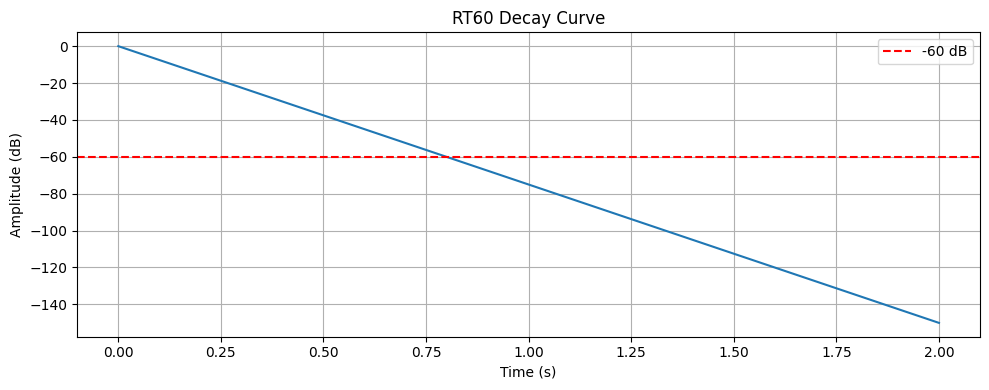

In [3]:
# Simulate RT_{60} decay
rT_{60} = 0.8  # seconds
t_decay = np.linspace(0, 2, 1000)
decay_curve = np.exp(-6.91 * t_decay / rT_{60})

plt.figure(figsize=(10, 4))
plt.plot(t_decay, 20 * np.log10(decay_curve))
plt.axhline(-60, color='red', linestyle='--', label='-60 dB')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (dB)")
plt.title("RT_{60} Decay Curve")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


With the simplified **Sabine formula**, assuming average absorption, the $T_{60}$ can be approximated as follows:

$$
T_{60} = \frac{0.161 \cdot V}{A}
$$

Where:
- $ V $: Volume of the room (in $ \text{m}^3 $)
- $ A $: Total absorption in sabins (assume $ A = \alpha \cdot S $)  
- $ \alpha $: Average absorption coefficient  
- $ S $: Surface area of the room (in $ \text{m}^2 $)  

For simplification, we use typical average absorption values and estimated room volumes to estimate the
$T_{60}$ for typical scenarios:

---

### Cathedral  
- Volume: $V = 10,000 \, \text{m}^3 $  
- Surface Area: $S = 3,000 \, \text{m}^2 $  
- Absorption Coefficient: $\alpha = 0.1 $

$$
A = 0.1 \cdot 3000 = 300 \, \text{sabins}
$$

$$
T_{60} = \frac{0.161 \cdot 10,000}{300} \approx \boxed{5.37 \, \text{seconds}}
$$

---

### Classroom  
- Volume: $V = 200 \, \text{m}^3 $  
- Surface Area: $S = 250 \, \text{m}^2 $  
- Absorption Coefficient: $\alpha = 0.3 $

$$
A = 0.3 \cdot 250 = 75 \, \text{sabins}
$$

$$
T_{60} = \frac{0.161 \cdot 200}{75} \approx \boxed{0.43 \, \text{seconds}}
$$

---

### Concert Hall  
- Volume: $V = 8,000 \, \text{m}^3 $  
- Surface Area: $S = 6,000 \, \text{m}^2 $  
- Absorption Coefficient: $\alpha = 0.1 $

$$
A = 0.1 \cdot 6000 = 600 \, \text{sabins}
$$

$$
T_{60} = \frac{0.161 \cdot 8000}{600} \approx \boxed{2.14 \, \text{seconds}}
$$


---

----

# Initial Time Delay Gap (ITDG)

The ITDG is the time that passes between the arrival of the direct sound and the first early reflections.
It depends mainly on the room dimensions.


A simplified equation for determining the ITDG:

$$
\text{ITDG} \approx \frac{2d}{c}
$$

Where:
- $ d $: Distance to nearest reflecting surface (m)  
- $ c $: Speed of sound (≈ 343 m/s)


The following examples calculate the ITDG for typical environments.

---

### Cathedral  
- Approx. reflection distance: $ d = 10 \, \text{m} $

$$
\text{ITDG} = \frac{2 \cdot 10}{343} \approx 0.058 \, \text{s} = \boxed{58 \, \text{ms}}
$$

---

### Classroom  
- Approx. reflection distance: $ d = 2.5 \, \text{m} $

$$
\text{ITDG} = \frac{2 \cdot 2.5}{343} \approx 0.0146 \, \text{s} = \boxed{14.6 \, \text{ms}}
$$

---

### Concert Hall  
- Approx. reflection distance: $ d = 6 \, \text{m} $

$$
\text{ITDG} = \frac{2 \cdot 6}{343} \approx 0.035 \, \text{s} = \boxed{35 \, \text{ms}}
$$

----

# Critical Distance 

The Critical Distance is the distance at which the intensity of the direct sound equals the intensity of the reverberant sound.
For an omnidirectional sound source, it can be simplified as:

$$
d_c ≈ 0.057 \frac{Q V}{T_{60}}
$$

With:
- $d_c$: critical distance in meters
- $V$: volume in $m^3$
- $Q$: directivity of the source (1 being omnidirectional)
- $T_{60}$: reverberation time in seconds.


The following examples calculate the critical distance for typical environments,
assuming a directivity of $2$, that is a good approximation for sources like the human voice, musical instruments and loudspeakers.

---

### Cathedral  

- $ V = 10,000 \, \text{m}^3 $  
- $ T_{60} = 6.0 \, \text{s} $  
- $ Q = 2 $

$$
D_c = 0.057 \cdot \sqrt{ \frac{2 \cdot 10,000}{6.0} } \approx 3.29 \, \text{m}
$$

---

### Classroom  
- $ V = 180 \, \text{m}^3 $  
- $ T_{60} = 0.8 \, \text{s} $

$$
D_c = 0.057 \cdot \sqrt{ \frac{2 \cdot 180}{0.8} } \approx 1.21 \, \text{m}
$$

---

### Concert Hall  
- $ V = 6000 \, \text{m}^3 $  
- $ T_{60} = 2.0 \, \text{s} $

$$
D_c = 0.057 \cdot \sqrt{ \frac{2 \cdot 6000}{2.0} } \approx 4.41 \, \text{m}
$$

----

These approximations for the critical distance tell us how important reverberation is for the quality of our everyday (and spcial occasion) acoustic experience. **In most situations the reverberation will have more energy than the direct sound at our listening position.**
